In [57]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt

def plot_results(folder, colors=None, xlabel="Time (years)", ylabels=None,
                 ylims=None, convert_to_years=True, average=True, num_hum=None, num_mos=None):

    # -----------------------------------------------------------
    # 1. Leer archivos Iteration_proof_*.txt
    # -----------------------------------------------------------
    pattern = os.path.join(folder, "Iteration_proof_*.txt")
    files = sorted(glob.glob(pattern))

    if len(files) == 0:
        print("No hay archivos Iteration_proof_*.txt en la carpeta.")
        return

    dfs = []
    for f in files:
        df = pd.read_csv(f, sep=";")
        dfs.append(df)

    df_all = pd.concat(dfs, ignore_index=True)

    # -----------------------------------------------------------
    # 2. Convertir time a años opcionalmente
    # -----------------------------------------------------------
    if convert_to_years:
        df_all["time_years"] = df_all["time"] / 365.0
        xname = "time_years"
    else:
        xname = "time"
        
    # -----------------------------------------------------------
    # 2. Convertir a Porcentajes las cosas
    # -----------------------------------------------------------
    df_all["HS"] = 100*df_all["HS"]/num_hum
    df_all["HM"] = 100*df_all["HM"]/num_hum
    df_all["HPC"] = 100*df_all["HPC"]/num_hum
    
    df_all["MS"] = 100*df_all["MS"]/num_mos
    df_all["MC"] = 100*df_all["MC"]/num_mos
    df_all["MPC"] = 100*df_all["MPC"]/num_mos   
    
    # -----------------------------------------------------------
    # 3. Calcular media y std
    # -----------------------------------------------------------
    if average:
        df_stats = df_all.groupby(xname).agg(['mean', 'std'])
        df_stats.columns = ['_'.join(col) for col in df_stats.columns]
        df_stats = df_stats.reset_index()
        df_all = df_stats

    # -----------------------------------------------------------
    # 4. Grupos de figuras
    # -----------------------------------------------------------
    groups = {
        "HS-HM-HPC": ["HS", "HM", "HPC"],
        "MC-MPC": ["MC", "MPC"],
        "ratio_reco": ["ratio_reco"],
        "num_haplotypes": ["num_haplotypes"],
        "MOI_Humans": ["MOI_Humans_mean", "MOI_Humans_median"],
        "MOI_Mosquitoes": ["MOI_Mosquitoes_mean", "MOI_Mosquitoes_median"],
        "SH": ["SH_Humans", "SH_Mosquitoes"],
        "PI": ["PI_Humans", "PI_Mosquitoes"],
        "lambda_h": ["lambda_h"],
        "lambda_v": ["lambda_v"]
    }

    # -----------------------------------------------------------
    # 5. Manejo de colores
    # -----------------------------------------------------------
    if colors is None:
        colors = {}

    for vars_list in groups.values():
        for var in vars_list:
            if var not in colors:
                colors[var] = None

    # -----------------------------------------------------------
    # 6. Graficar con ylabels personalizados y y-lims
    # -----------------------------------------------------------
    for title, vars_list in groups.items():

        ylabel = "Value"  # default
        if ylabels is not None and title in ylabels:
            ylabel = ylabels[title]

        plt.figure(figsize=(7, 5))

        for var in vars_list:
            mean_col = var + "_mean"
            std_col  = var + "_std"

            if mean_col in df_all.columns:
                plt.plot(df_all[xname], df_all[mean_col],
                         label=var, color=colors[var])

                plt.fill_between(df_all[xname],
                                 df_all[mean_col] - df_all[std_col],
                                 df_all[mean_col] + df_all[std_col],
                                 color=colors[var], alpha=0.25)

        # EJE Y: aplicar límites si están definidos
        if ylims is not None and title in ylims:
            plt.ylim(ylims[title][0], ylims[title][1])

        plt.xlabel(xlabel, fontsize=12)
        plt.ylabel(ylabel, fontsize=12)
        plt.grid(axis='y', alpha=0.5)
        plt.legend()
        plt.show()

    return df_all

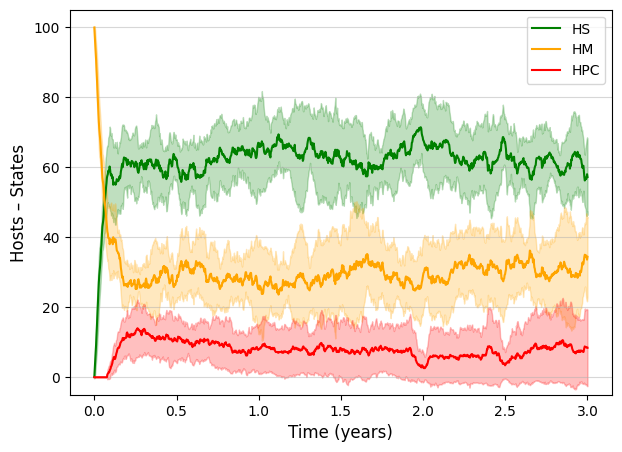

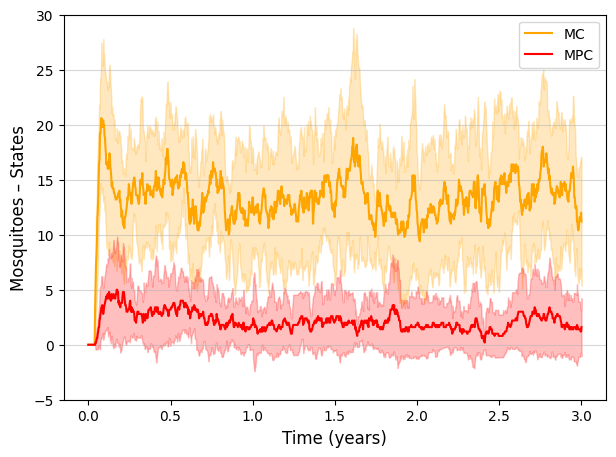

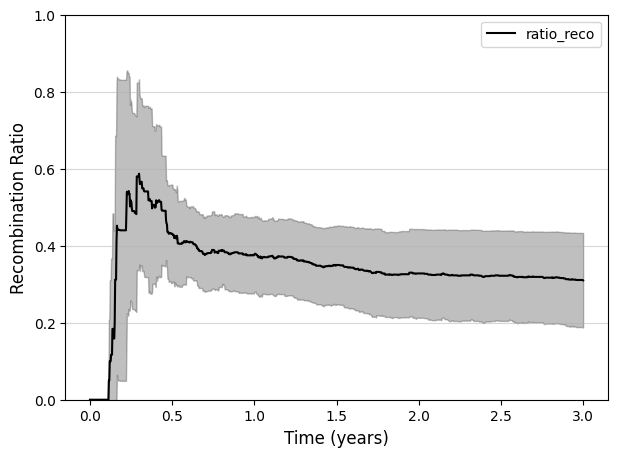

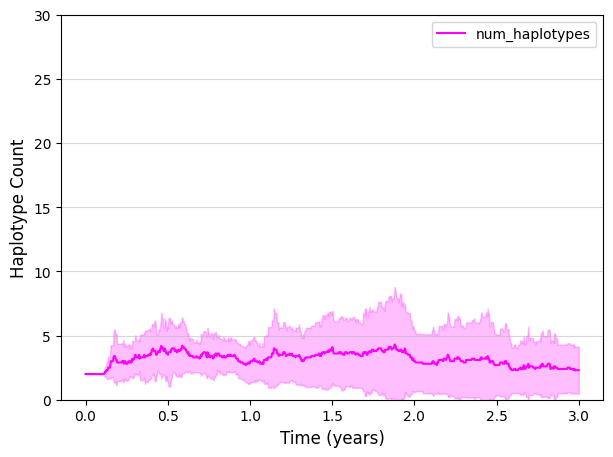

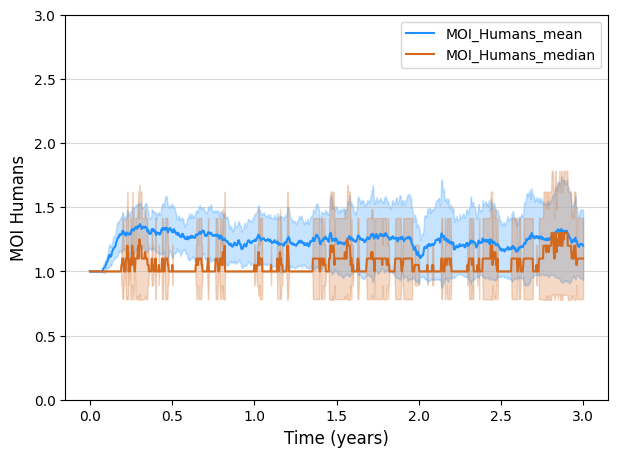

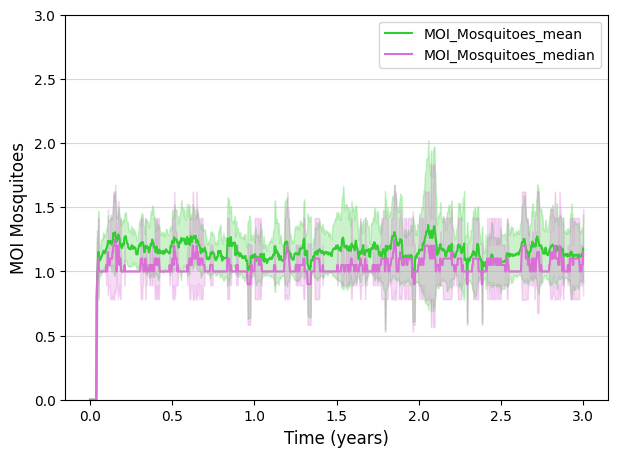

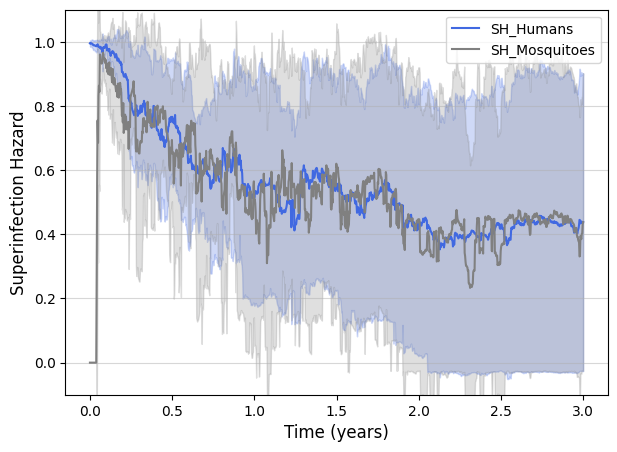

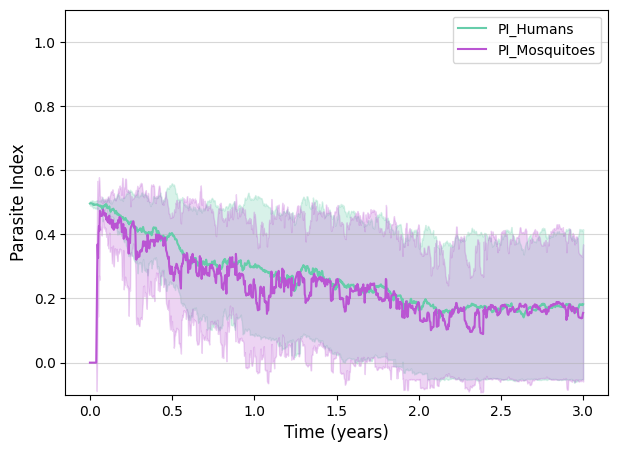

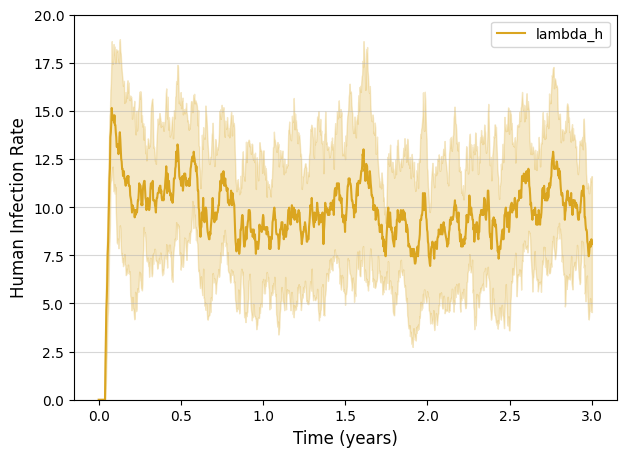

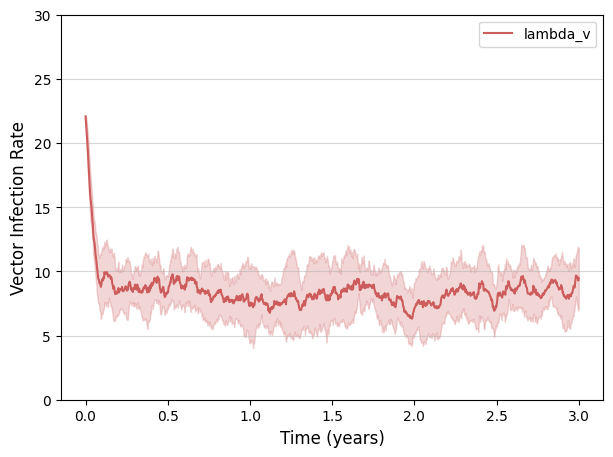

In [59]:
colors = {"HS": "green", "HM": "orange", "HPC": "red",
          "MS": "green", "MC": "orange", "MPC": "red",
          "ratio_reco": "black",
          "num_haplotypes": "magenta",
          "MOI_Humans_mean": "dodgerblue", "MOI_Humans_median": "chocolate",
          "MOI_Mosquitoes_mean": "limegreen", "MOI_Mosquitoes_median": "orchid",
          "SH_Humans": "royalblue", "SH_Mosquitoes": "gray",
          "PI_Humans": "mediumaquamarine", "PI_Mosquitoes": "mediumorchid",
          "lambda_h": "goldenrod", "lambda_v": "indianred"}

ylabels = {"HS-HM-HPC": "Hosts – States",
           "MC-MPC": "Mosquitoes – States",
           "ratio_reco": "Recombination Ratio",
           "num_haplotypes": "Haplotype Count",
           "MOI_Humans": "MOI Humans",
           "MOI_Mosquitoes": "MOI Mosquitoes",
           "SH": "Superinfection Hazard",
           "PI": "Parasite Index",
           "lambda_h": "Human Infection Rate",
           "lambda_v": "Vector Infection Rate"}

ylims = {"HS-HM-HPC": (-5, 105),
         "MC-MPC": (-5, 30),
         "ratio_reco": (0, 1),
         "num_haplotypes": (0, 30),
         "MOI_Humans": (0, 3),
         "MOI_Mosquitoes": (0, 3),
         "SH": (-0.1, 1.1),
         "PI": (-0.1, 1.1),
         "lambda_h": (0, 20),
         "lambda_v": (0, 30)}

num_humans = 50
mos_x_human = 1
num_mosquitoes = num_humans*mos_x_human

df = plot_results(f"./results/IGD_50_BR_1.2_NH_{num_humans}_MxH_{mos_x_human}",
                  colors=colors, xlabel="Time (years)", ylabels=ylabels,
                  convert_to_years=True, average=True,ylims=ylims, 
                  num_hum = num_humans, num_mos = num_mosquitoes )

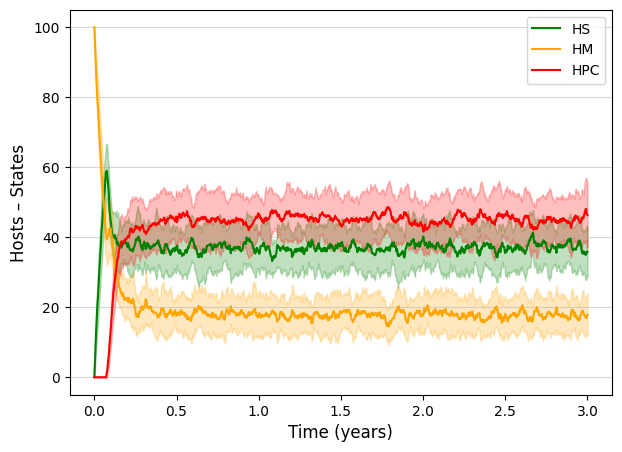

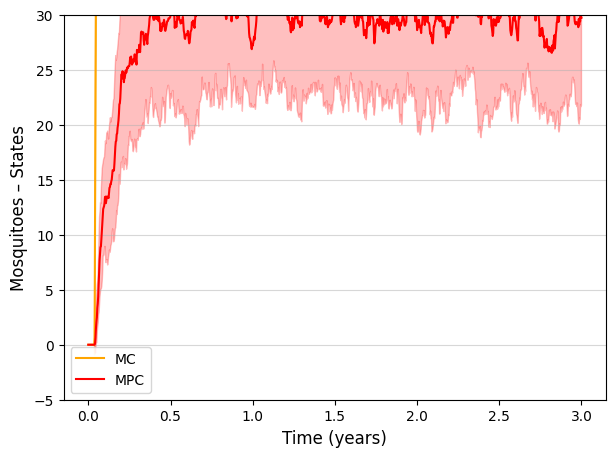

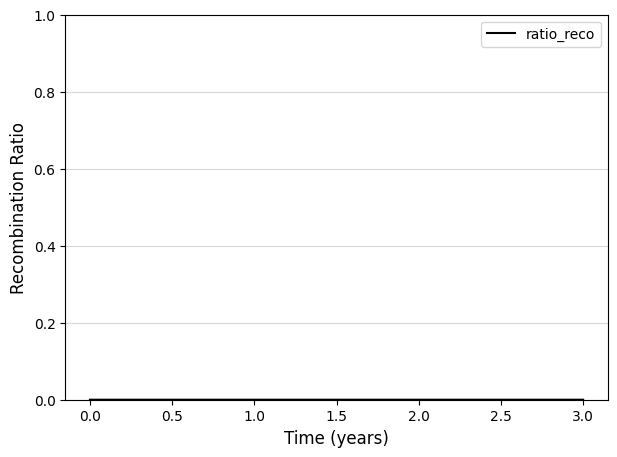

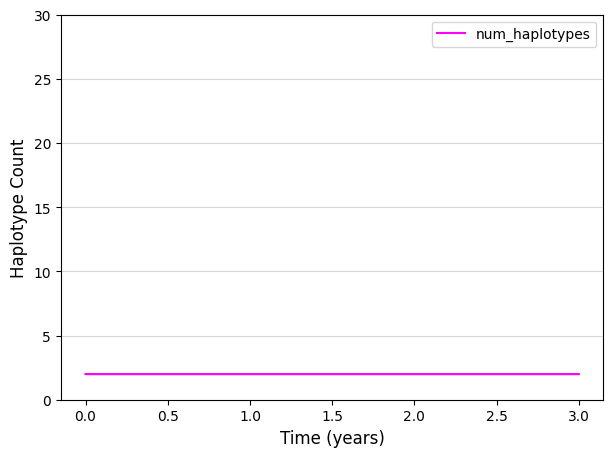

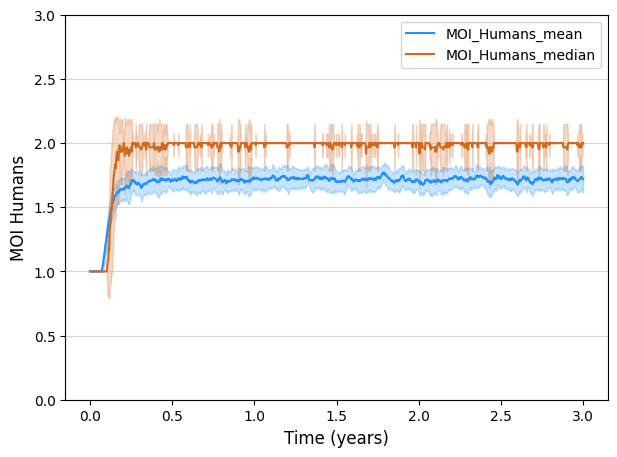

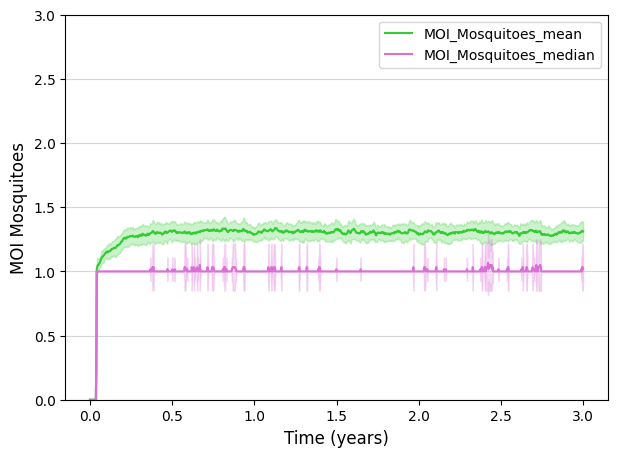

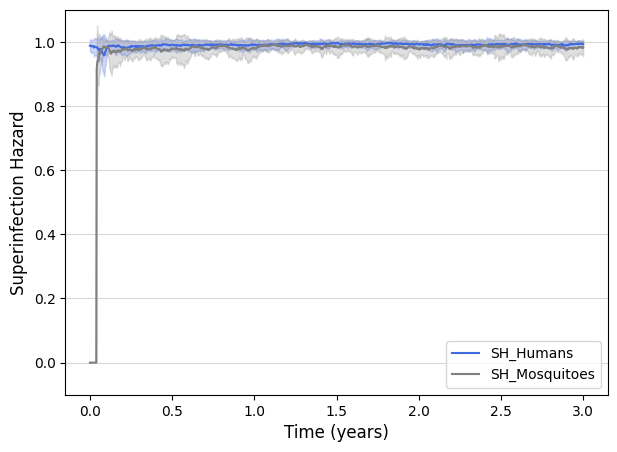

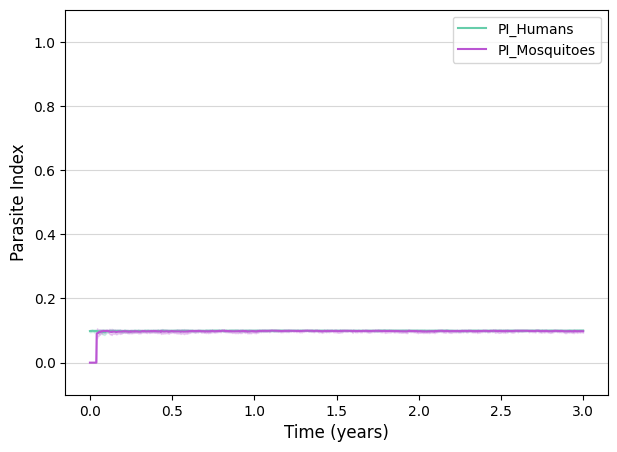

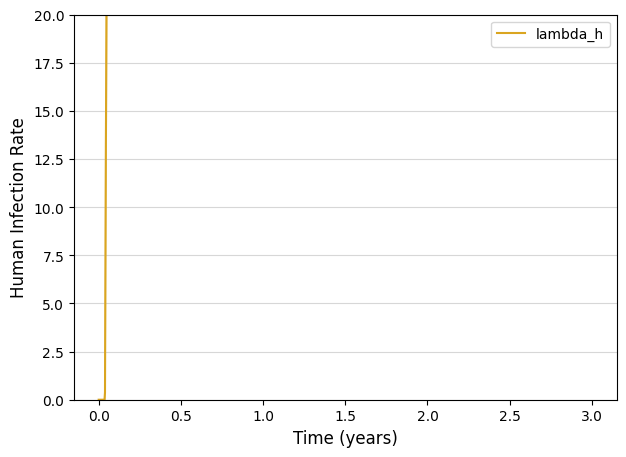

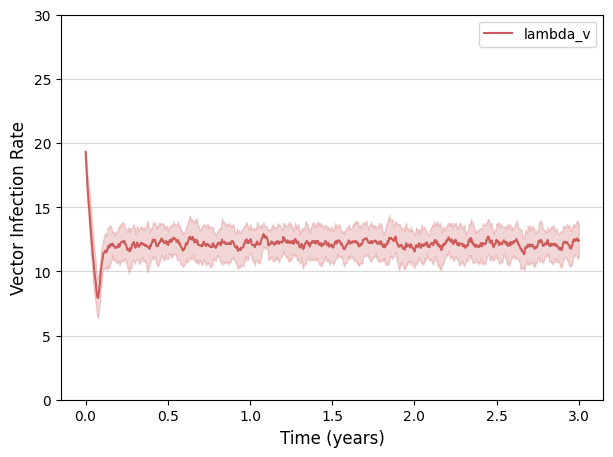

In [65]:
df = plot_results(f"./results/IGD_10_BR_5.0_NH_50_MxH_5",
                  colors=colors, xlabel="Time (years)", ylabels=ylabels,
                  convert_to_years=True, average=True,ylims=ylims, 
                  num_hum = num_humans, num_mos = num_mosquitoes )